## Generate Data

In [3]:
import numpy as np
from astropy.table import Table

STAMP_DIR  = "/astro/store/epyc4/data4/kbmod_runs/DEEP/ml_classifier/for_hurum/"
XMATCH_DIR = "/astro/store/epyc4/data4/kbmod_runs/DEEP/5sigma_run/xmatch_catalogs/"
SAVE_DIR   = "/astro/store/epyc/ssd/users/htohfa/"

# 7 sigma data
tp_7s = np.load(STAMP_DIR + "true_positive_stamps_full.npy")   
fp_7s = np.load(STAMP_DIR + "false_positive_stamps_full.npy")  

stamps_5s = np.load(STAMP_DIR + "DEEP_lh5_stamps.npy")
uuids_5s  = np.load(STAMP_DIR + "DEEP_lh5_uuids.npy", allow_pickle=True)
xmatch    = Table.read(XMATCH_DIR + "xmatch_catalog.angular_50percent_cut.ecsv", format="ascii.ecsv")
real_uuids = set(str(u).strip() for u in xmatch["uuid"])
labels_5s  = np.array([1 if str(u).strip() in real_uuids else 0 for u in uuids_5s])
tp_5s = stamps_5s[labels_5s == 1]
fp_5s = stamps_5s[labels_5s == 0]

# Combine
tp_combined = np.concatenate([tp_7s, tp_5s], axis=0)
fp_combined = np.concatenate([fp_7s, fp_5s], axis=0)

print(f"TP total: {len(tp_combined):7d}  (7σ={len(tp_7s)}, 5σ={len(tp_5s)})")
print(f"FP total: {len(fp_combined):7d}  (7σ={len(fp_7s)}, 5σ={len(fp_5s)})")
print(f"Ratio FP:TP = {len(fp_combined)/len(tp_combined):.1f}:1")

# checking normalizing 
def normalize_stamps(stamps):
    out  = stamps.astype(np.float32)
    flat = out.reshape(len(out), -1)
    mu   = flat.mean(axis=1, keepdims=True)
    sig  = flat.std(axis=1,  keepdims=True)
    sig[sig == 0] = 1.0
    return ((flat - mu) / sig).reshape(out.shape)

tp_norm = normalize_stamps(tp_combined)
fp_norm = normalize_stamps(fp_combined)

print(f" Post processing ")
print(f"TP  mean={tp_norm.mean():.4f}  std={tp_norm.std():.4f}  min={tp_norm.min():.2f}  max={tp_norm.max():.2f}")
print(f"FP  mean={fp_norm.mean():.4f}  std={fp_norm.std():.4f}  min={fp_norm.min():.2f}  max={fp_norm.max():.2f}")


tp_flat = tp_norm.reshape(len(tp_norm), -1)
fp_flat = fp_norm.reshape(len(fp_norm), -1)

print(f"  TP max/stamp mean: {tp_flat.max(1).mean():.4f}")
print(f"  FP max/stamp mean: {fp_flat.max(1).mean():.4f}")


np.save(SAVE_DIR + "tp_combined_5_7sigma.npy", tp_combined)  
np.save(SAVE_DIR + "fp_combined_5_7sigma.npy", fp_combined)


TP total:   34440  (7σ=12809, 5σ=21631)
FP total: 1019269  (7σ=157900, 5σ=861369)
Ratio FP:TP = 29.6:1
 Post processing 
TP  mean=-0.0000  std=1.0000  min=-15.06  max=21.00
FP  mean=0.0000  std=0.9999  min=-24.04  max=30.00
  TP max/stamp mean: 8.4137
  FP max/stamp mean: 7.1372


Loaded — TP: 34440, FP: 1019269
FP subsampled: 300000  (7σ=157900, 5σ=142100)
TP total     : 34440
Ratio FP:TP  = 8.7:1
Train:  234108  (TP=24108, FP=210000)
Val  :   50166  (TP=5166, FP=45000)
Test :   50166  (TP=5166, FP=45000)
Parameters: 899,858
Epoch   1/50  train=0.0380  val=0.0355  AUC=0.9909  AP=0.9515
  ↑ saved (AUC=0.9909)
Epoch   2/50  train=0.0326  val=0.0228  AUC=0.9888  AP=0.9376
Epoch   3/50  train=0.0305  val=0.0393  AUC=0.9909  AP=0.9507
Epoch   4/50  train=0.0296  val=0.0377  AUC=0.9911  AP=0.9515
  ↑ saved (AUC=0.9911)
Epoch   5/50  train=0.0281  val=0.0315  AUC=0.9916  AP=0.9545
  ↑ saved (AUC=0.9916)
Epoch   6/50  train=0.0277  val=0.0300  AUC=0.9917  AP=0.9550
  ↑ saved (AUC=0.9917)
Epoch   7/50  train=0.0261  val=0.0272  AUC=0.9931  AP=0.9600
  ↑ saved (AUC=0.9931)
Epoch   8/50  train=0.0254  val=0.0263  AUC=0.9929  AP=0.9601
Epoch   9/50  train=0.0250  val=0.0353  AUC=0.9918  AP=0.9547
Epoch  10/50  train=0.0246  val=0.0226  AUC=0.9922  AP=0.9573
Epoch  11/50  t

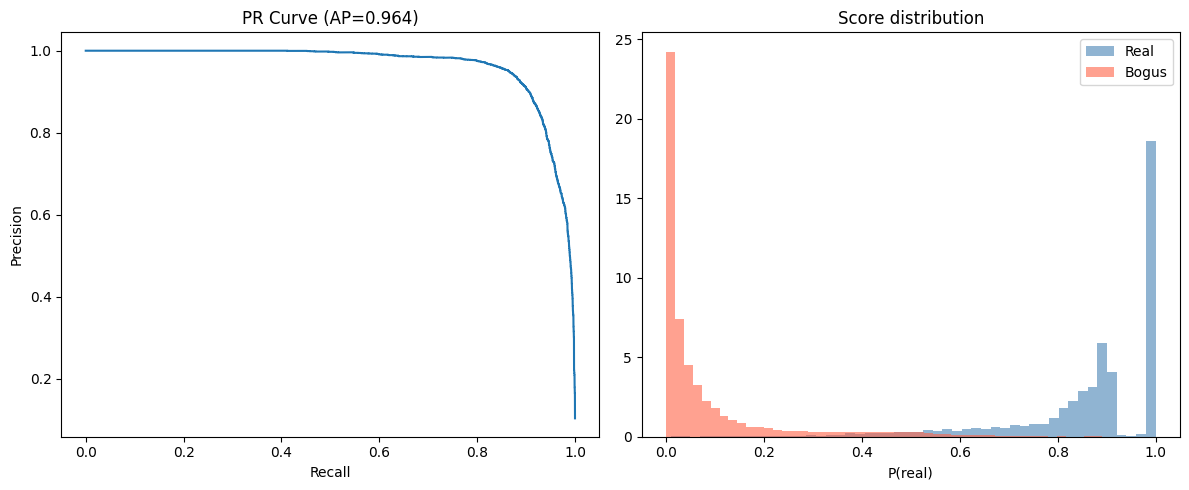

Precision / Recall
  Recall≥0.99  →  Precision=0.4931  threshold=0.230
  Recall≥0.95  →  Precision=0.7533  threshold=0.490
  Recall≥0.90  →  Precision=0.9096  threshold=0.622
  Recall≥0.80  →  Precision=0.9752  threshold=0.778


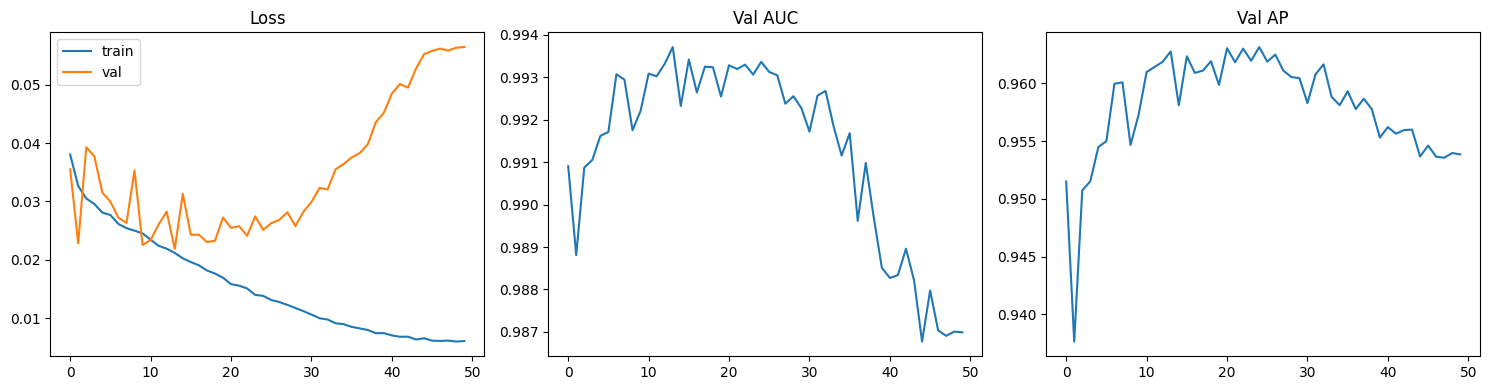

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import os

SAVE_DIR  = "/astro/store/epyc/ssd/users/htohfa/"

tp = np.load(SAVE_DIR + "tp_combined_5_7sigma.npy")
fp = np.load(SAVE_DIR + "fp_combined_5_7sigma.npy")

print(f"Loaded — TP: {len(tp)}, FP: {len(fp)}")

#dont wanna train on everything 
N_FP_TARGET  = 300_000
N_FP_7S      = 157_900
N_FP_5S_ORIG = len(fp) - N_FP_7S

n_5s_needed  = N_FP_TARGET - N_FP_7S
rng          = np.random.default_rng(42)
idx_5s       = rng.choice(N_FP_5S_ORIG, size=n_5s_needed, replace=False) + N_FP_7S

fp_sub = np.concatenate([fp[:N_FP_7S], fp[idx_5s]], axis=0)

print(f"FP subsampled: {len(fp_sub)}  (7σ={N_FP_7S}, 5σ={n_5s_needed})")
print(f"TP total     : {len(tp)}")
print(f"Ratio FP:TP  = {len(fp_sub)/len(tp):.1f}:1")

def normalize_stamps(stamps):
    out  = stamps.astype(np.float32)
    flat = out.reshape(len(out), -1)
    mu   = flat.mean(axis=1, keepdims=True)
    sig  = flat.std(axis=1,  keepdims=True)
    sig[sig == 0] = 1.0
    return ((flat - mu) / sig).reshape(out.shape)

class StampDataset(Dataset):
    def __init__(self, stamps, labels, augment=False):
        self.stamps  = torch.tensor(normalize_stamps(stamps), dtype=torch.float32)
        self.labels  = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.stamps)

    def __getitem__(self, idx):
        x = self.stamps[idx]
        y = self.labels[idx]
        if self.augment:
            x = torch.rot90(x, torch.randint(0, 4, ()).item(), dims=[1, 2])
            if torch.rand(1).item() > 0.5: x = torch.flip(x, dims=[2])
            if torch.rand(1).item() > 0.5: x = torch.flip(x, dims=[1])
            x = x + torch.randn_like(x) * 0.05
        return x, y


def make_datasets(tp, fp, val_frac=0.15, test_frac=0.15, seed=42):
    rng = np.random.default_rng(seed)

    def split(arr):
        idx    = rng.permutation(len(arr))
        n_test = int(len(arr) * test_frac)
        n_val  = int(len(arr) * val_frac)
        return arr[idx[n_val+n_test:]], arr[idx[n_test:n_test+n_val]], arr[idx[:n_test]]

    tp_tr, tp_va, tp_te = split(tp)
    fp_tr, fp_va, fp_te = split(fp)

    def combine(a, b):
        return (np.concatenate([a, b]),
                np.array([1]*len(a) + [0]*len(b)))

    tr_s, tr_l = combine(tp_tr, fp_tr)
    va_s, va_l = combine(tp_va, fp_va)
    te_s, te_l = combine(tp_te, fp_te)

    print(f"Train: {len(tr_s):7d}  (TP={len(tp_tr)}, FP={len(fp_tr)})")
    print(f"Val  : {len(va_s):7d}  (TP={len(tp_va)}, FP={len(fp_va)})")
    print(f"Test : {len(te_s):7d}  (TP={len(tp_te)}, FP={len(fp_te)})")

    return (StampDataset(tr_s, tr_l, augment=True),
            StampDataset(va_s, va_l, augment=False),
            StampDataset(te_s, te_l, augment=False),
            tr_l)


def make_loader(dataset, labels=None, batch_size=256, balance=True):
    if balance and labels is not None:
        n_real  = (labels == 1).sum()
        n_bogus = (labels == 0).sum()
        w       = np.where(labels == 1, 1.0/n_real, 1.0/n_bogus)
        sampler = WeightedRandomSampler(torch.tensor(w, dtype=torch.float32), len(w))
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=4, pin_memory=True)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False,
                      num_workers=4, pin_memory=True)


class SEBlock(nn.Module):
    def __init__(self, c, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(c, c//r), nn.ReLU(),
            nn.Linear(c//r, c), nn.Sigmoid()
        )
    def forward(self, x):
        w = x.mean(dim=[2, 3])
        return x * self.fc(w).unsqueeze(-1).unsqueeze(-1)

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False),
            nn.BatchNorm2d(c), nn.GELU(),
            nn.Conv2d(c, c, 3, padding=1, bias=False),
            nn.BatchNorm2d(c),
        )
        self.se  = SEBlock(c)
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.se(self.conv(x)) + x)

class KBModNet(nn.Module):
    def __init__(self, in_channels=3, base=32, dropout=0.3):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(in_channels, base, 3, padding=1, bias=False),
            nn.BatchNorm2d(base), nn.GELU(),
        )
        self.layer1 = nn.Sequential(ResBlock(base),   ResBlock(base))
        self.down1  = nn.Sequential(
            nn.Conv2d(base, base*2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base*2), nn.GELU(),
        )
        self.layer2 = nn.Sequential(ResBlock(base*2), ResBlock(base*2))
        self.down2  = nn.Sequential(
            nn.Conv2d(base*2, base*4, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base*4), nn.GELU(),
        )
        self.layer3 = nn.Sequential(ResBlock(base*4), ResBlock(base*4))
        self.head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base*4, base*2), nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(base*2, 2),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.down1(x)
        x = self.layer2(x)
        x = self.down2(x)
        x = self.layer3(x)
        return self.head(x)

##changed loss function
def focal_loss(logits, targets, gamma=2.0):
    ce = F.cross_entropy(logits, targets, reduction="none")
    return ((1 - torch.exp(-ce)) ** gamma * ce).mean()


def train(model, train_loader, val_loader, epochs=50, lr=3e-4, device="cuda"):
    model    = model.to(device)
    opt      = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    history  = {"train_loss": [], "val_loss": [], "val_auc": [], "val_ap": []}
    best_auc = 0.0

    for epoch in range(epochs):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = focal_loss(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        sched.step()

        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_losses.append(focal_loss(model(x), y).item())
                probs = F.softmax(model(x), dim=1)[:, 1].cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(y.cpu().numpy())

        auc = roc_auc_score(all_labels, all_probs)
        ap  = average_precision_score(all_labels, all_probs)
        history["train_loss"].append(np.mean(losses))
        history["val_loss"].append(np.mean(val_losses))
        history["val_auc"].append(auc)
        history["val_ap"].append(ap)

        print(f"Epoch {epoch+1:3d}/{epochs}  train={np.mean(losses):.4f}  "
              f"val={np.mean(val_losses):.4f}  AUC={auc:.4f}  AP={ap:.4f}")

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), SAVE_DIR + "best_kbmodnet_5_7sigma.pt")
            print(f"  ↑ saved (AUC={auc:.4f})")

    return history


def evaluate(model, test_loader, device="cuda"):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            probs = F.softmax(model(x.to(device)), dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    ap  = average_precision_score(all_labels, all_probs)
    print(f"\nTest AUC={auc:.4f}  AP={ap:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    prec, rec, thr = precision_recall_curve(all_labels, all_probs)
    axes[0].plot(rec, prec)
    axes[0].set_xlabel("Recall");  axes[0].set_ylabel("Precision")
    axes[0].set_title(f"PR Curve (AP={ap:.3f})")

    axes[1].hist(all_probs[all_labels==1], bins=50, alpha=0.6,
                 color="steelblue", label="Real", density=True)
    axes[1].hist(all_probs[all_labels==0], bins=50, alpha=0.6,
                 color="tomato", label="Bogus", density=True)
    axes[1].set_xlabel("P(real)")
    axes[1].set_title("Score distribution")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "test_evaluation_5_7sigma.png", dpi=150)
    plt.show()


    print("Precision / Recall")
    for target_rec in [0.99, 0.95, 0.90, 0.80]:
        idx = np.where(rec >= target_rec)[0]
        if len(idx):
            i = idx[-1]
            print(f"  Recall≥{target_rec:.2f}  →  Precision={prec[i]:.4f}  threshold={thr[i] if i < len(thr) else 1.0:.3f}")

    return all_probs, all_labels


if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
 

    train_ds, val_ds, test_ds, train_labels = make_datasets(tp, fp_sub)
    train_loader = make_loader(train_ds, train_labels, batch_size=256, balance=True)
    val_loader   = make_loader(val_ds,   batch_size=256, balance=False)
    test_loader  = make_loader(test_ds,  batch_size=256, balance=False)

    model = KBModNet(in_channels=3, base=32, dropout=0.3)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    history = train(model, train_loader, val_loader, epochs=50, lr=3e-4, device=device)

    model.load_state_dict(torch.load(SAVE_DIR + "best_kbmodnet_5_7sigma.pt"))
    model = model.to(device)
    probs, labels = evaluate(model, test_loader, device=device)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"],   label="val")
    axes[0].set_title("Loss");  axes[0].legend()
    axes[1].plot(history["val_auc"]);  axes[1].set_title("Val AUC")
    axes[2].plot(history["val_ap"]);   axes[2].set_title("Val AP")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "training_curves_5_7sigma.png", dpi=150)
    plt.show()
  


7σ
  AUC=1.0000  AP=1.0000  Acc=0.9992
  Recall=0.9999  Precision=0.9896  FPR=0.0008
  TP=12,808  FP=134  TN=157,766  FN=1

5σ
  AUC=0.9855  AP=0.7673  Acc=0.9715
  Recall=0.8740  Precision=0.4572  FPR=0.0261
  TP=18,906  FP=22,450  TN=838,919  FN=2,725

combined
  AUC=0.9923  AP=0.9007  Acc=0.9760
  Recall=0.9208  Precision=0.5841  FPR=0.0222
  TP=31,714  FP=22,584  TN=996,685  FN=2,726
  only 1 available for 'xmatch YES, nn NO  (model missed)'


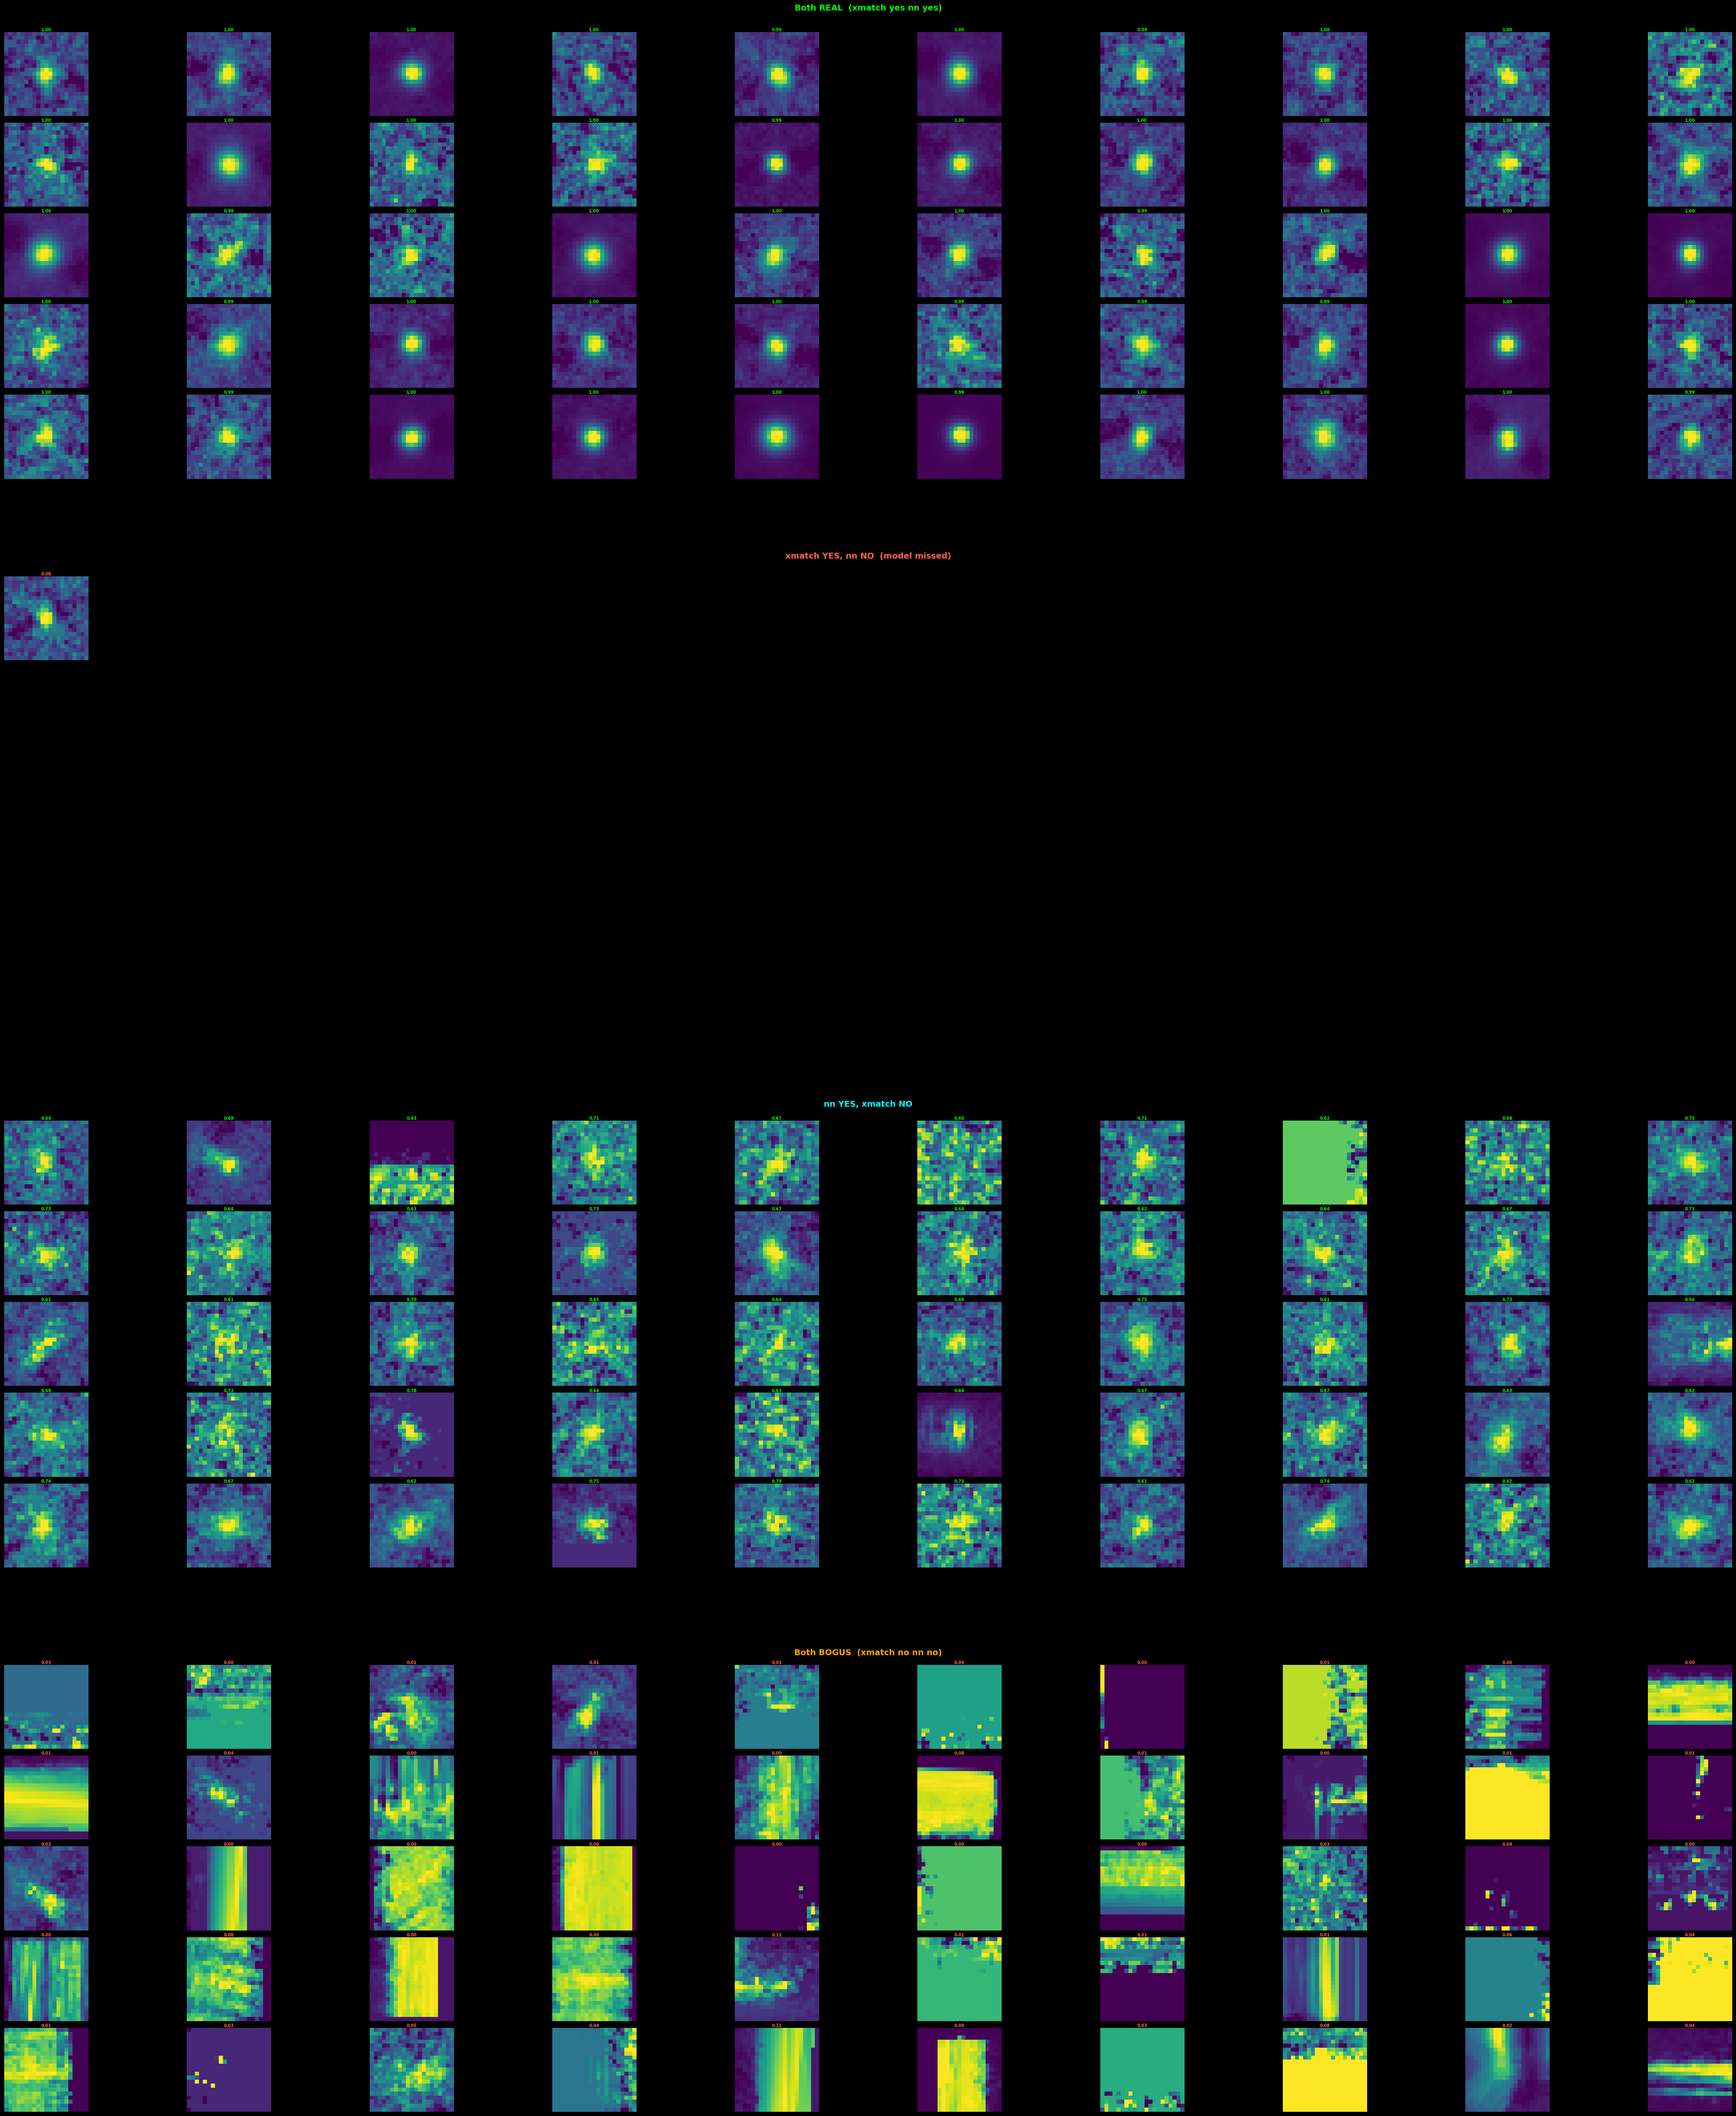

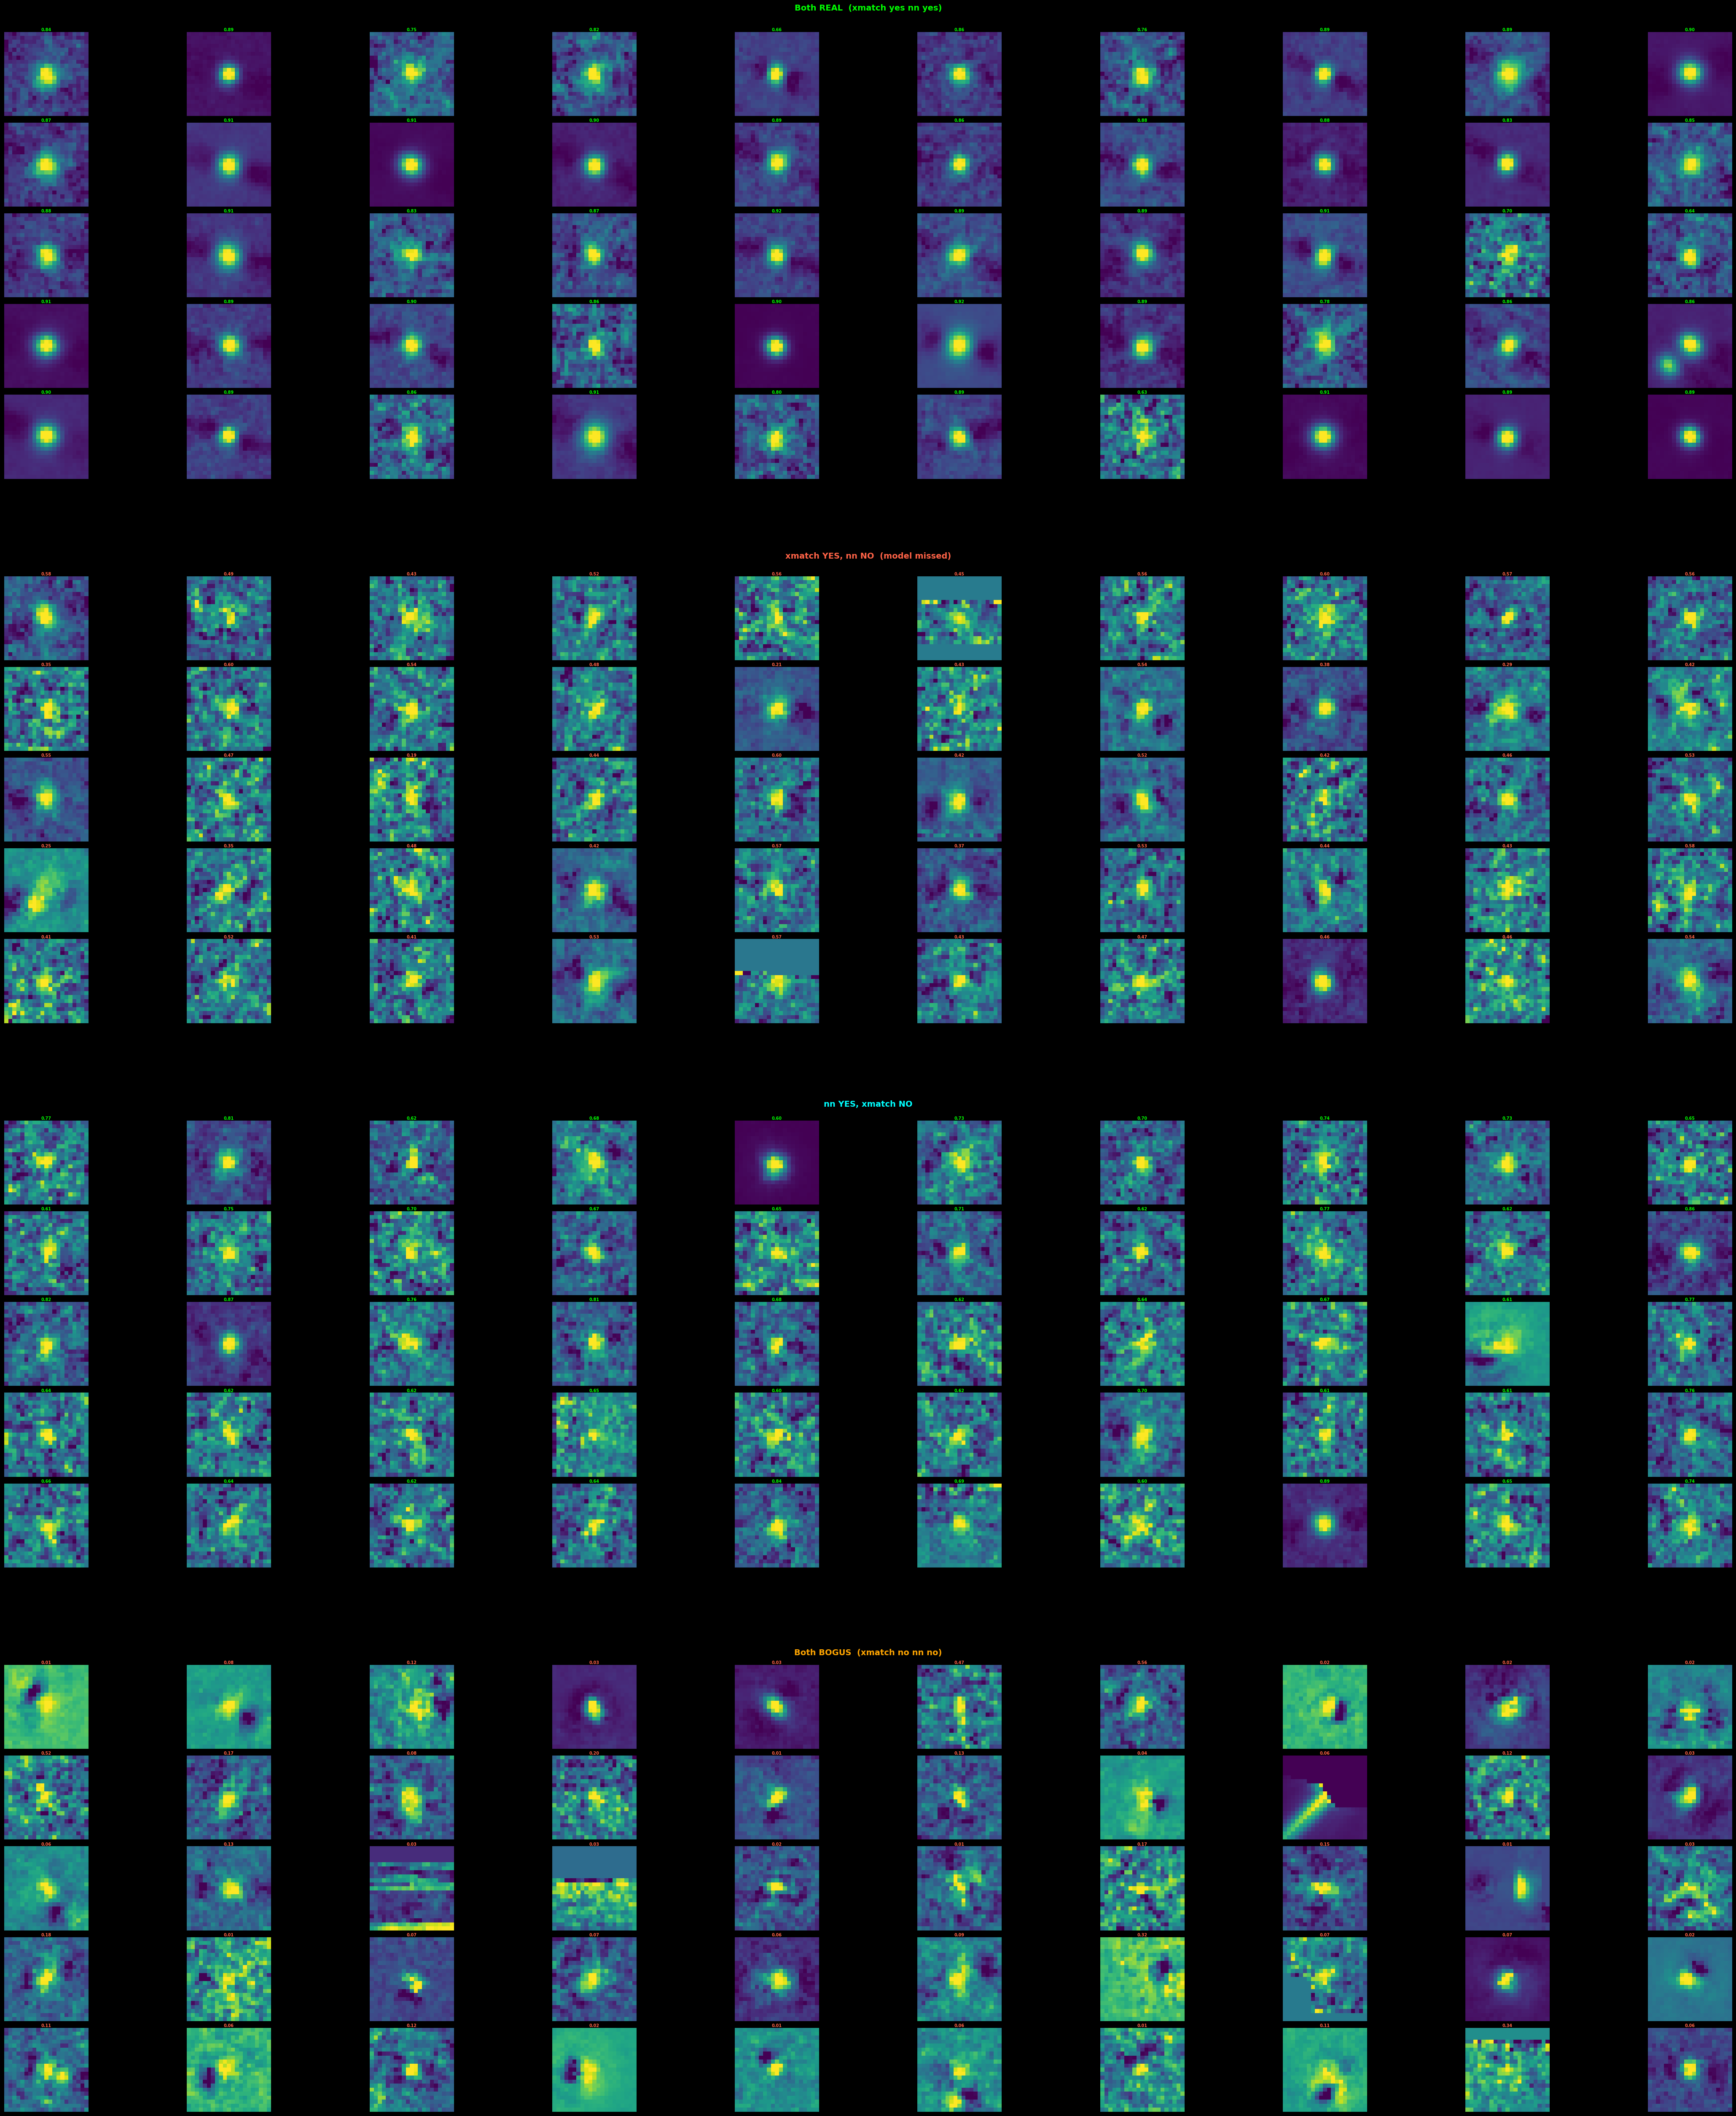

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from astropy.table import Table
import os

STAMP_DIR  = "/astro/store/epyc4/data4/kbmod_runs/DEEP/ml_classifier/for_hurum/"
XMATCH_DIR = "/astro/store/epyc4/data4/kbmod_runs/DEEP/5sigma_run/xmatch_catalogs/"
SAVE_DIR   = "/astro/store/epyc/ssd/users/htohfa/"
THRESHOLD  = 0.6

class SEBlock(nn.Module):
    def __init__(self, c, r=4):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(c, c//r), nn.ReLU(),
                                nn.Linear(c//r, c), nn.Sigmoid())
    def forward(self, x):
        w = x.mean(dim=[2,3])
        return x * self.fc(w).unsqueeze(-1).unsqueeze(-1)

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.GELU(),
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c))
        self.se = SEBlock(c); self.act = nn.GELU()
    def forward(self, x): return self.act(self.se(self.conv(x)) + x)

class KBModNet(nn.Module):
    def __init__(self, in_channels=3, base=32, dropout=0.3):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(in_channels, base, 3, padding=1, bias=False),
                                    nn.BatchNorm2d(base), nn.GELU())
        self.layer1 = nn.Sequential(ResBlock(base),   ResBlock(base))
        self.down1  = nn.Sequential(nn.Conv2d(base, base*2, 3, stride=2, padding=1, bias=False),
                                    nn.BatchNorm2d(base*2), nn.GELU())
        self.layer2 = nn.Sequential(ResBlock(base*2), ResBlock(base*2))
        self.down2  = nn.Sequential(nn.Conv2d(base*2, base*4, 3, stride=2, padding=1, bias=False),
                                    nn.BatchNorm2d(base*4), nn.GELU())
        self.layer3 = nn.Sequential(ResBlock(base*4), ResBlock(base*4))
        self.head   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                    nn.Dropout(dropout), nn.Linear(base*4, base*2),
                                    nn.GELU(), nn.Dropout(dropout/2), nn.Linear(base*2, 2))
    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.down1(x)
        x = self.layer2(x); x = self.down2(x); x = self.layer3(x)
        return self.head(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = KBModNet()
model.load_state_dict(torch.load(SAVE_DIR + "best_kbmodnet_5_7sigma.pt", map_location=device))
model  = model.to(device).eval()

def normalize_stamps(stamps):
    out  = stamps.astype(np.float32)
    flat = out.reshape(len(out), -1)
    mu   = flat.mean(axis=1, keepdims=True)
    sig  = flat.std(axis=1, keepdims=True); sig[sig==0] = 1.0
    return ((flat - mu) / sig).reshape(out.shape)

class InferenceDataset(Dataset):
    def __init__(self, stamps):
        self.stamps = torch.tensor(normalize_stamps(stamps), dtype=torch.float32)
    def __len__(self): return len(self.stamps)
    def __getitem__(self, i): return self.stamps[i]

def run_inference(stamps):
    loader = DataLoader(InferenceDataset(stamps), batch_size=512,
                        shuffle=False, num_workers=4, pin_memory=True)
    probs = []
    with torch.no_grad():
        for x in loader:
            probs.extend(F.softmax(model(x.to(device)), dim=1)[:,1].cpu().numpy())
    return np.array(probs)

def print_stats(name, probs_tp, probs_fp, thr=THRESHOLD):
    probs  = np.concatenate([probs_tp, probs_fp])
    labels = np.array([1]*len(probs_tp) + [0]*len(probs_fp))
    preds  = (probs >= thr).astype(int)
    tn, fp_n, fn, tp_n = confusion_matrix(labels, preds).ravel()
    auc  = roc_auc_score(labels, probs)
    ap   = average_precision_score(labels, probs)
    rec  = tp_n / (tp_n + fn)
    prec = tp_n / (tp_n + fp_n) if (tp_n + fp_n) > 0 else 0
    fpr  = fp_n / (fp_n + tn)
    acc  = (tp_n + tn) / len(labels)
    print(f"\n{name}")
    print(f"  AUC={auc:.4f}  AP={ap:.4f}  Acc={acc:.4f}")
    print(f"  Recall={rec:.4f}  Precision={prec:.4f}  FPR={fpr:.4f}")
    print(f"  TP={tp_n:,}  FP={fp_n:,}  TN={tn:,}  FN={fn:,}")

def plot_cases(sigma_label, stamps, probs_all, xmatch_labels, n=50, fname_suffix=""):
    nn_pred = (probs_all >= THRESHOLD).astype(int)
    xm      = xmatch_labels
    cases = {
        "Both REAL  (xmatch yes nn yes)":          np.where((xm==1) & (nn_pred==1))[0],
        "xmatch YES, nn NO  (model missed)":  np.where((xm==1) & (nn_pred==0))[0],
        "nn YES, xmatch NO":         np.where((xm==0) & (nn_pred==1))[0],
        "Both BOGUS  (xmatch no nn no)":         np.where((xm==0) & (nn_pred==0))[0],
    }
    title_colors = ["lime", "tomato", "cyan", "orange"]
    n_cols      = 10
    n_rows_each = n // n_cols
    total_rows  = n_rows_each * 4 + 3

    fig = plt.figure(figsize=(44, total_rows * 2.2))
    fig.patch.set_facecolor("black")


    gs = fig.add_gridspec(total_rows, n_cols, hspace=0.08, wspace=0.05,
                          left=0.01, right=0.99, top=0.985, bottom=0.01)

    rng_plot   = np.random.default_rng(99)
    row_offset = 0

    for panel_i, (case_title, idx_pool) in enumerate(cases.items()):
        color  = title_colors[panel_i]
        sample = (rng_plot.choice(idx_pool, size=min(n, len(idx_pool)), replace=False)
                  if len(idx_pool) >= n else idx_pool)

        fig.text(0.5, 1 - (row_offset / total_rows) * 0.985 - 0.002,
                 case_title, ha="center", va="top", fontsize=14,
                 color=color, fontweight="bold", transform=fig.transFigure)

        for i, idx in enumerate(sample[:n]):
            r, c  = divmod(i, n_cols)
            stamp = stamps[idx, 0].astype(np.float32)
            prob  = probs_all[idx]
            vmin  = np.nanpercentile(stamp, 1)
            vmax  = np.nanpercentile(stamp, 99)
            if vmax == vmin: vmax = vmin + 1e-6
            ax = fig.add_subplot(gs[row_offset + r, c])
            ax.imshow(stamp, origin="lower", cmap="viridis",
                      vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_facecolor("black")
            ax.set_title(f"{prob:.2f}", fontsize=7, pad=1.5, fontweight="bold",
                         color="lime" if prob >= THRESHOLD else "tomato")
            ax.axis("off")

        if len(sample) < n:
            print(f"  only {len(sample)} available for '{case_title}'")

        row_offset += n_rows_each
        if panel_i < 3:
            row_offset += 1

    plt.savefig(SAVE_DIR + f"cases_{fname_suffix}.png", dpi=110,
                bbox_inches="tight", facecolor="black")
    plt.show()

# load data
tp_all = np.load(SAVE_DIR + "tp_combined_5_7sigma.npy")
fp_all = np.load(SAVE_DIR + "fp_combined_5_7sigma.npy")

# reproduce the same FP subsample used in training
rng_sub     = np.random.default_rng(42)
N_FP_7S     = 157_900
n_5s_needed = 300_000 - N_FP_7S
idx_5s      = rng_sub.choice(len(fp_all) - N_FP_7S, size=n_5s_needed, replace=False) + N_FP_7S
fp_sub      = np.concatenate([fp_all[:N_FP_7S], fp_all[idx_5s]], axis=0)

# split out 5σ vs 7σ
N_TP_7S      = 12_809
tp_7s        = tp_all[:N_TP_7S]
fp_7s        = fp_all[:N_FP_7S]

stamps_5s    = np.load(STAMP_DIR + "DEEP_lh5_stamps.npy")
uuids_5s     = np.array([str(u).strip() for u in
                          np.load(STAMP_DIR + "DEEP_lh5_uuids.npy", allow_pickle=True)])
xmatch       = Table.read(XMATCH_DIR + "xmatch_catalog.angular_50percent_cut.ecsv",
                           format="ascii.ecsv")
real_uuids   = set(str(u).strip() for u in xmatch["uuid"])
labels_5s    = np.array([1 if u in real_uuids else 0 for u in uuids_5s])
tp_5s        = stamps_5s[labels_5s == 1]
fp_5s        = stamps_5s[labels_5s == 0]


probs_tp_7s = run_inference(tp_7s)
probs_fp_7s = run_inference(fp_7s)
probs_tp_5s = run_inference(tp_5s)
probs_fp_5s = run_inference(fp_5s)

# stats
print_stats("7σ", probs_tp_7s, probs_fp_7s)
print_stats("5σ", probs_tp_5s, probs_fp_5s)
print_stats("combined", np.concatenate([probs_tp_7s, probs_tp_5s]),
                        np.concatenate([probs_fp_7s, probs_fp_5s]))

# plots
plot_cases("7σ",
           np.concatenate([tp_7s, fp_7s]),
           np.concatenate([probs_tp_7s, probs_fp_7s]),
           np.array([1]*len(tp_7s) + [0]*len(fp_7s)),
           n=50, fname_suffix="7sigma")

plot_cases("5σ",
           np.concatenate([tp_5s, fp_5s]),
           np.concatenate([probs_tp_5s, probs_fp_5s]),
           np.array([1]*len(tp_5s) + [0]*len(fp_5s)),
           n=50, fname_suffix="5sigma")

